In [20]:
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np

In [21]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [22]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

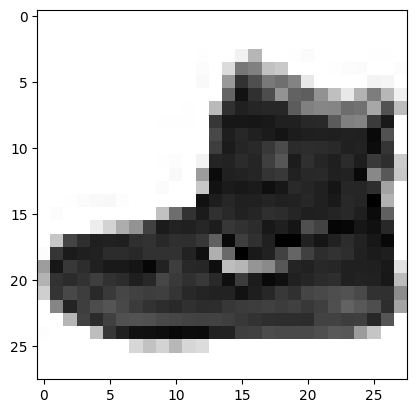

Label: 9


In [23]:
## Visualizando imagens

imagem = x_train[0]
classe_da_imagem = y_train[0]
plt.imshow(imagem.reshape(28,28), cmap=plt.cm.binary)
plt.show()
print("Label: {}".format(classe_da_imagem))

In [24]:
# 1. Mapeamento para a classificação binária
# Frio: 1, 2, 4, 9 -> 0
# Calor: 0, 3, 5, 6, 7, 8 -> 1
print("Mapeando as classes para Frio (0) e Calor (1)...")
y_train_binary = np.isin(y_train, [0, 3, 5, 6, 7, 8]).astype(int)
y_test_binary = np.isin(y_test, [0, 3, 5, 6, 7, 8]).astype(int)

Mapeando as classes para Frio (0) e Calor (1)...


In [25]:
# 2. Normalização e redimensionamento das imagens
print("Normalizando e redimensionando as imagens...")
x_train_processed = x_train.astype("float32") / 255.0
x_test_processed = x_test.astype("float32") / 255.0

x_train_processed = x_train_processed.reshape(-1, 28, 28, 1)
x_test_processed = x_test_processed.reshape(-1, 28, 28, 1)

Normalizando e redimensionando as imagens...


In [26]:
# 3. Construção da CNN
print("Construindo o modelo da CNN...")
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Saída única com sigmóide para binário
])

Construindo o modelo da CNN...


c:\Users\joao1\OneDrive\Documentos\SistemasDeInformacao8Periodo\IA\ml-supervised-dev\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# 4. Compilação do modelo
print("Compilando o modelo...")
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Loss para classificação binária
              metrics=['accuracy'])

print("\n--- Resumo do Modelo ---")
model.summary()
print("------------------------\n")

Compilando o modelo...

--- Resumo do Modelo ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,345 (474.00 KB)

 Trainable params: 121,345 (474.00 KB)

 Non-trainable params: 0 (0.00 B)

------------------------



In [28]:
# 5. Treinamento do modelo
print("Iniciando o treinamento do modelo...")
history = model.fit(x_train_processed, y_train_binary, epochs=10, validation_data=(x_test_processed, y_test_binary))
print("Treinamento concluído.\n")

Iniciando o treinamento do modelo...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8762 - loss: 0.2703 - val_accuracy: 0.9319 - val_loss: 0.1641
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9407 - loss: 0.1467 - val_accuracy: 0.9365 - val_loss: 0.1558
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9484 - loss: 0.1275 - val_accuracy: 0.9442 - val_loss: 0.1350
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9535 - loss: 0.1150 - val_accuracy: 0.9398 - val_loss: 0.1482
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9605 - loss: 0.0997 - val_accuracy: 0.9503 - val_loss: 0.1243
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9617 - loss: 0.0944 - val_accuracy: 0.9548 - val_loss: 0.1244
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9663 - loss: 0.0844 - val_accuracy: 0.9520 - val_loss: 0.1304
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━

In [29]:
# 6. Avaliação do modelo
print("Avaliando a performance do modelo...")
test_loss, test_acc = model.evaluate(x_test_processed, y_test_binary, verbose=2)
print(f'\nAcurácia final no conjunto de teste: {test_acc:.4f}')

Avaliando a performance do modelo...
313/313 - 2s - 7ms/step - accuracy: 0.9540 - loss: 0.1217

Acurácia final no conjunto de teste: 0.9540


Gerando gráficos de acurácia e perda...


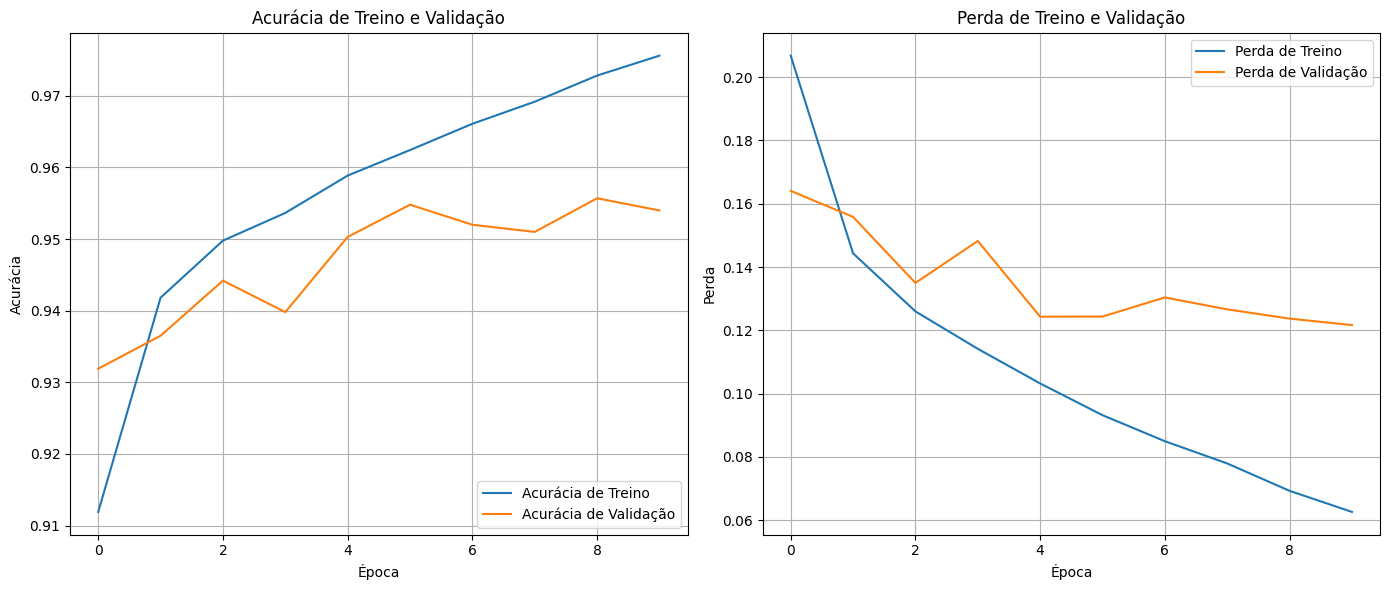


Gráficos salvos como 'accuracy_plot.png' e 'loss_plot.png'.


In [31]:
# 7. Plotando os resultados
print("Gerando gráficos de acurácia e perda...")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.title('Acurácia de Treino e Validação')
plt.grid(True)
plt.savefig('accuracy_plot.png')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda de Treino')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend(loc='upper right')
plt.title('Perda de Treino e Validação')
plt.grid(True)
plt.savefig('loss_plot.png')

plt.tight_layout()
plt.show()

print("\nGráficos salvos como 'accuracy_plot.png' e 'loss_plot.png'.")